plotted


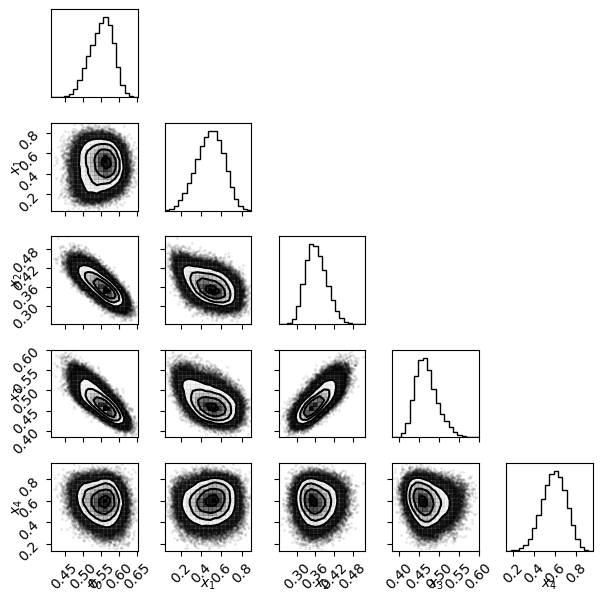

In [1]:
import dill
import matplotlib.pyplot as plt

with open("/home/andrew/abm_violence/models/nooptstate-v3/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp = vbmc_loaded.vp
vp.plot()
print("plotted")


In [7]:
samples, _ = vp.sample(int(1e5))
from gvabm.param_distr import ParamDistr, param_config
param_distr = ParamDistr(param_config)
samples = param_distr.expand_range(samples)
# ref_samples.mean(axis=0)
# walk_in_range = (ref_samples[:, 0] < -6.2) & (ref_samples[:, 0] > -6.25) 
# samples = ref_samples[walk_in_range]

In [8]:
# print(param_label_map)
param_units = ['Agent / Person / Year', 'Miles', 'Sites / Sq Mile', 'Unitless', 'Gathering / Person']

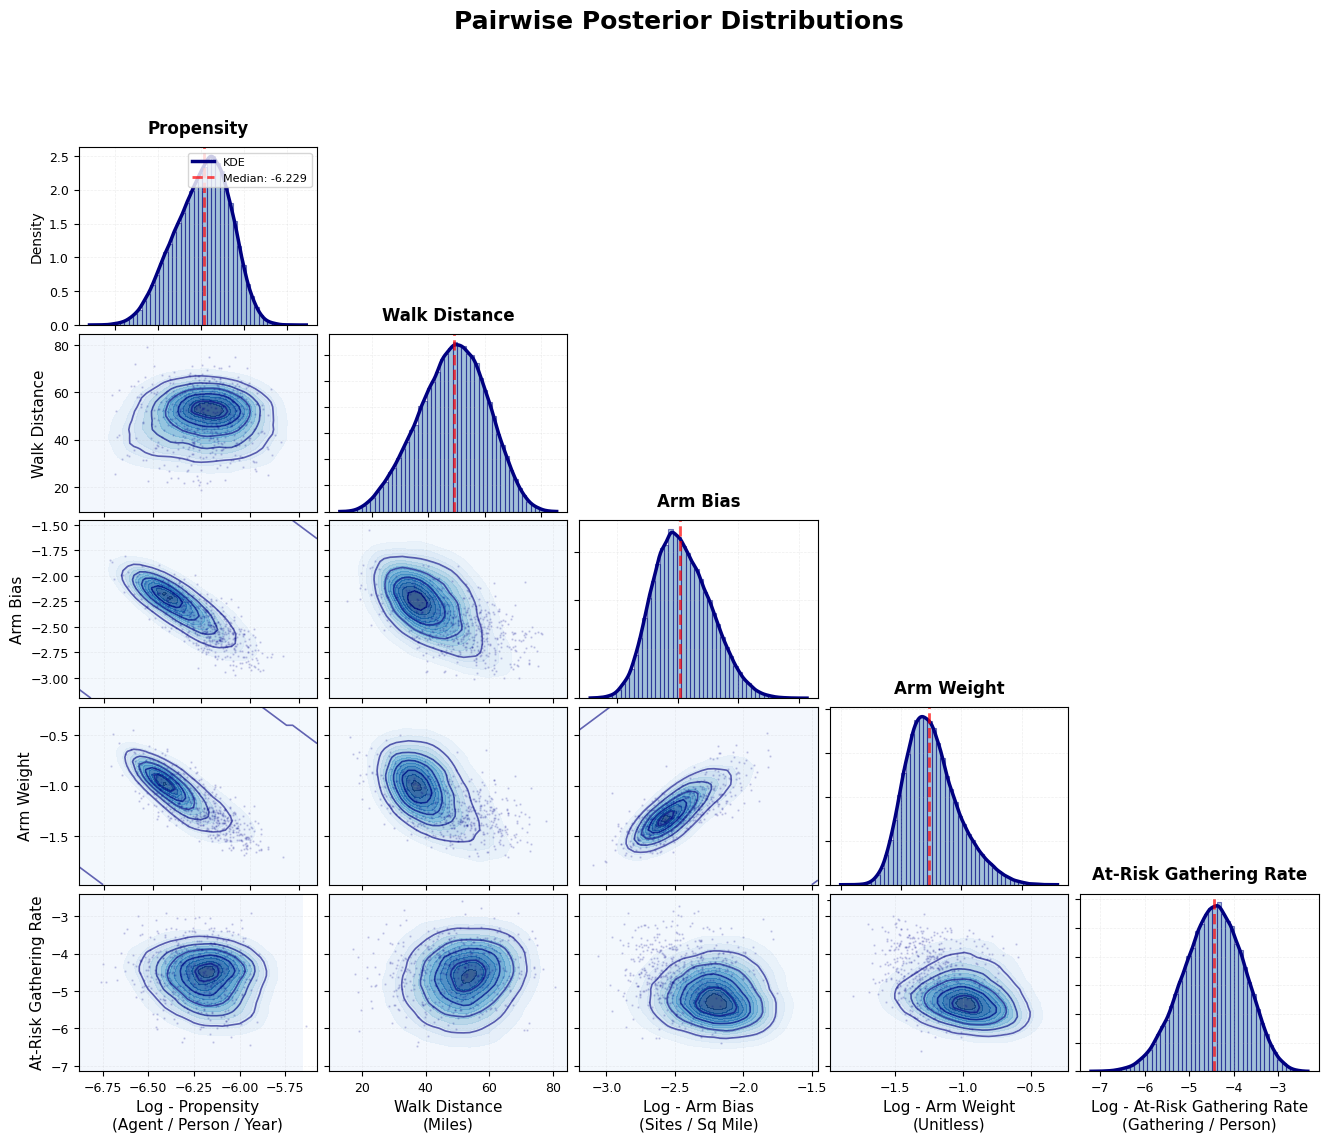


Correlation Matrix:
Parameter correlations:
  propensity                × arm_bias                 :  -0.792
  propensity                × arm_weight               :  -0.794
  walk_radius               × arm_bias                 :  -0.479
  walk_radius               × arm_weight               :  -0.481
  arm_bias                  × arm_weight               :   0.767


In [12]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np
from ref import param_label_map


# Create figure with better spacing
fig, axes = plt.subplots(len(param_distr.param_names), len(param_distr.param_names), 
                         figsize=(16, 12))
plt.subplots_adjust(hspace=0.05, wspace=0.05)

for i in range(len(param_distr.param_names)):
    for j in range(len(param_distr.param_names)):
        ax = axes[i, j]
        
        if i < j:
            # Upper triangle: turn off
            ax.axis('off')
            
        elif i > j:
            # Lower triangle: 2D density plots with contours
            x_data = samples[:, j]
            y_data = samples[:, i]
            
            # Create 2D histogram for background
            h, xedges, yedges = np.histogram2d(x_data, y_data, bins=40)
            
            # Create meshgrid for contours
            x_centers = (xedges[:-1] + xedges[1:]) / 2
            y_centers = (yedges[:-1] + yedges[1:]) / 2
            X, Y = np.meshgrid(x_centers, y_centers)

            h_smoothed = gaussian_kde(np.vstack([x_data, y_data]))(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
            
            # Plot filled contours
            contourf = ax.contourf(X, Y, h_smoothed.T, levels=15, cmap='Blues', alpha=0.8)

            # Add contour lines
            contour = ax.contour(X, Y, h_smoothed.T, levels=5, colors='navy', 
                                linewidths=1.2, alpha=0.6)
            
            sample_indices = np.random.choice(len(x_data), size=min(500, len(x_data)), replace=False)
            ax.scatter(x_data[sample_indices], y_data[sample_indices], 
                      s=0.5, alpha=0.15, color='darkblue', rasterized=True)
            
            # Add labels for contour lines (optional)
            # ax.clabel(contour, inline=True, fontsize=8, fmt='%1.0f')
            
            # Set labels only on edges
            if j == 0:
                ax.set_ylabel(param_label_map[param_distr.param_names[i]], fontsize=11)
            else:
                ax.set_yticklabels([])
                
            if i == len(param_distr.param_names) - 1:
                ax.set_xlabel(f"{'Log - ' if param_distr.logscale[j] else ''}{param_label_map[param_distr.param_names[j]]}\n({param_units[j]})", fontsize=11)
            else:
                ax.set_xticklabels([])
            
            # Style improvements
            ax.tick_params(labelsize=9)
            ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
            
        else:
            # Diagonal: marginal distributions with KDE
            data = samples[:, i]
            
            # Create histogram
            counts, bins, _ = ax.hist(data, bins=50, density=True, alpha=0.5, 
                                     color='steelblue', edgecolor='navy', linewidth=0.8)
            
            # Add KDE smooth curve
            kde = gaussian_kde(data)
            x_range = np.linspace(data.min(), data.max(), 300)
            kde_values = kde(x_range)
            ax.plot(x_range, kde_values, 'navy', linewidth=2.5, label='KDE')
            
            # Add median line
            median_val = np.median(data)
            ax.axvline(median_val, color='red', linestyle='--', linewidth=2, 
                      alpha=0.7, label=f'Median: {median_val:.3f}')
            
            # Set title only for diagonal
            ax.set_title(param_label_map[param_distr.param_names[i]], 
                        fontsize=12, fontweight='bold', pad=10)
            
            # Set labels
            if i == len(param_distr.param_names) - 1:
                ax.set_xlabel(f"{'Log - ' if param_distr.logscale[j] else ''}{param_label_map[param_distr.param_names[j]]}\n({param_units[j]})", fontsize=11)
                
            if j == 0:
                ax.set_ylabel('Density', fontsize=10)
            else:
                ax.set_yticklabels([])
            
            # Add legend only to first diagonal plot
            if i == 0:
                ax.legend(fontsize=8, loc='upper right')
            
            # Style improvements
            ax.tick_params(labelsize=9)
            ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# Overall title
fig.suptitle('Pairwise Posterior Distributions', fontsize=18, fontweight='bold', y=0.995)

plt.savefig('/home/andrew/abm_violence/paper_code/images/posterior_pairwise.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Print correlation matrix
print("\nCorrelation Matrix:")
print("=" * 80)
corr_matrix = np.corrcoef(samples.T)
print("Parameter correlations:")
for i in range(len(param_distr.param_names)):
    for j in range(i+1, len(param_distr.param_names)):
        corr = corr_matrix[i, j]
        if abs(corr) > 0.3:  # Only show notable correlations
            print(f"  {param_distr.param_names[i]:25s} × {param_distr.param_names[j]:25s}: {corr:7.3f}")


In [5]:
from ref import param_names, param_label_map
import numpy as np
import matplotlib.pyplot as plt

KeyboardInterrupt: 

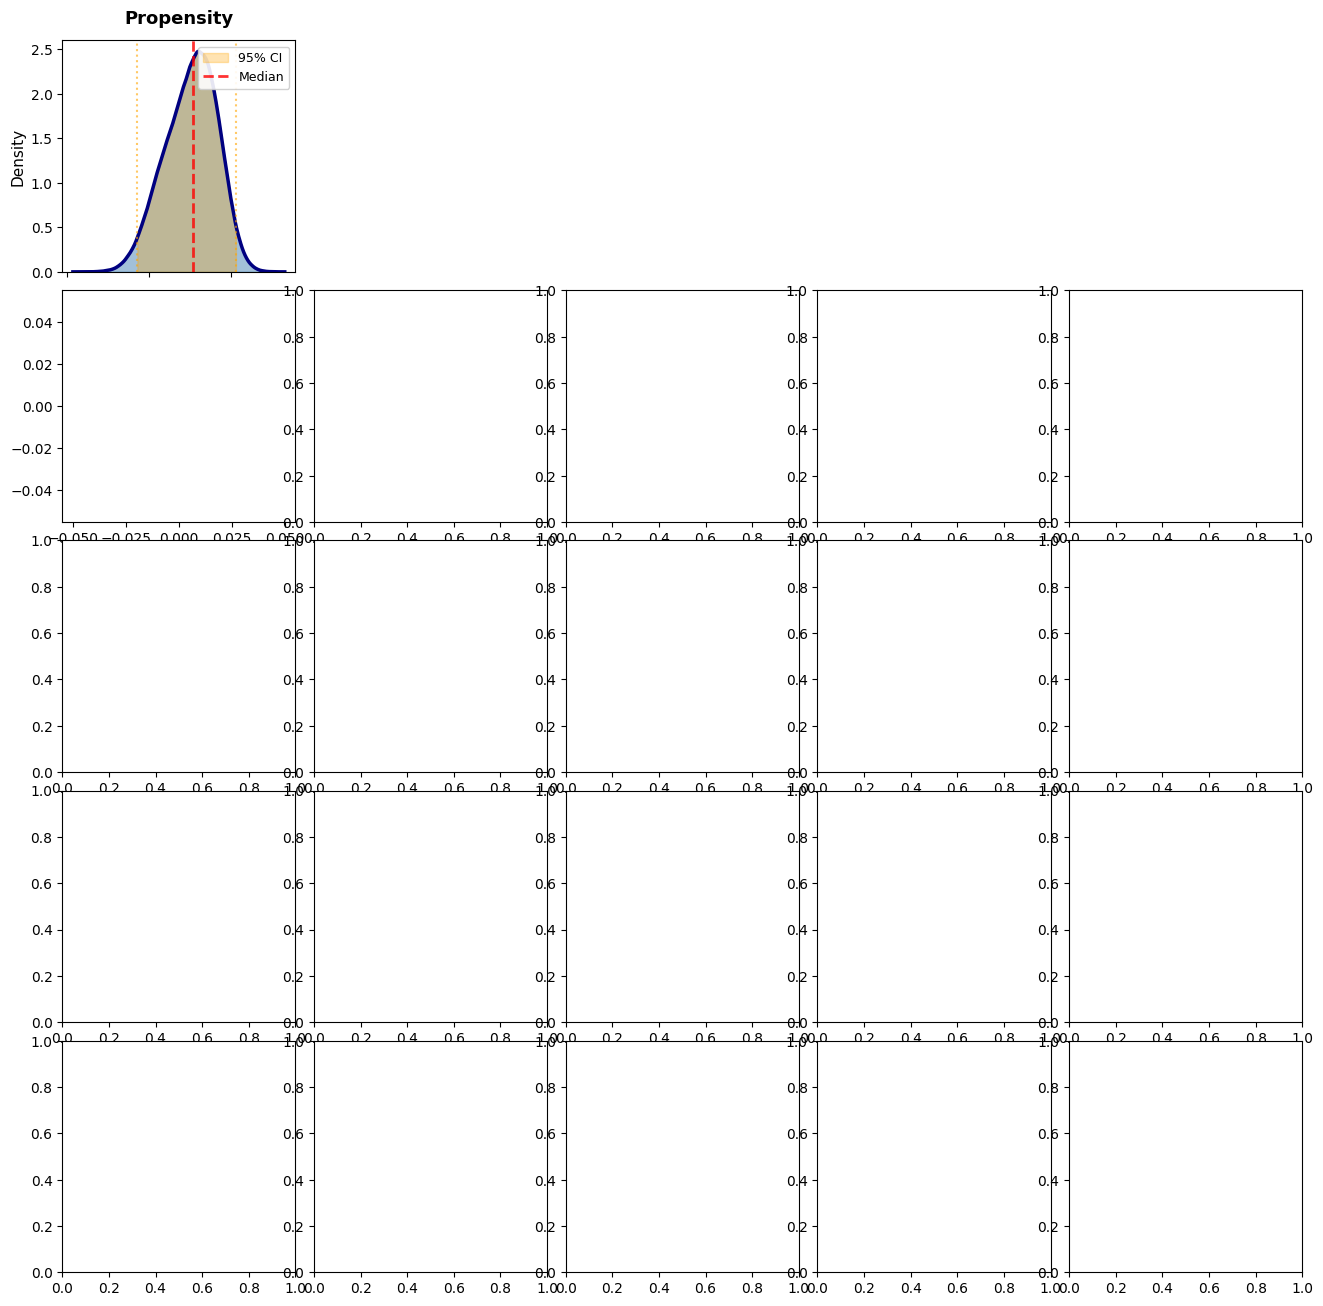

In [6]:
# Alternative: Using seaborn's KDE plot for smoother contours
import seaborn as sns
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(len(param_distr.param_names), len(param_distr.param_names), 
                         figsize=(16, 16))
plt.subplots_adjust(hspace=0.08, wspace=0.08)

for i in range(len(param_distr.param_names)):
    for j in range(len(param_distr.param_names)):
        ax = axes[i, j]
        
        if i < j:
            ax.axis('off')
            
        elif i > j:
            # Lower triangle: seaborn KDE plot with filled contours
            x_data = samples[:, j]
            y_data = samples[:, i]
            
            # Use seaborn's kdeplot for smooth contours
            sns.kdeplot(x=x_data, y=y_data, ax=ax, 
                       fill=True, levels=10, cmap='Blues', alpha=0.7)
            
            # Add contour lines
            sns.kdeplot(x=x_data, y=y_data, ax=ax, 
                       fill=False, levels=5, color='navy', 
                       linewidths=1.5, alpha=0.8)
            
            # Add scatter of a sample of points for texture
            sample_indices = np.random.choice(len(x_data), size=min(500, len(x_data)), replace=False)
            ax.scatter(x_data[sample_indices], y_data[sample_indices], 
                      s=0.5, alpha=0.15, color='darkblue', rasterized=True)
            
            # Labels
            if j == 0:
                ax.set_ylabel(param_label_map[param_distr.param_names[i]], 
                            fontsize=12, fontweight='bold')
            else:
                ax.set_ylabel('')
                ax.set_yticklabels([])
                
            if i == len(param_distr.param_names) - 1:
                ax.set_xlabel(f"{param_label_map[param_distr.param_names[j]]}\n({param_units[j]})", 
                            fontsize=12, fontweight='bold')
            else:
                ax.set_xlabel('')
                ax.set_xticklabels([])
            
            ax.tick_params(labelsize=10)
            
        else:
            # Diagonal: marginal distributions
            data = samples[:, i]
            
            # KDE plot
            kde = gaussian_kde(data)
            x_range = np.linspace(data.min(), data.max(), 300)
            kde_values = kde(x_range)
            
            # Fill under curve
            ax.fill_between(x_range, kde_values, alpha=0.5, color='steelblue')
            ax.plot(x_range, kde_values, color='navy', linewidth=2.5)
            
            # Add quantiles
            q2_5 = np.percentile(data, 2.5)
            q97_5 = np.percentile(data, 97.5)
            median_val = np.median(data)
            
            # Shade 95% credible interval
            mask = (x_range >= q2_5) & (x_range <= q97_5)
            ax.fill_between(x_range[mask], kde_values[mask], 
                           alpha=0.3, color='orange', label='95% CI')
            
            # Add vertical lines
            ax.axvline(median_val, color='red', linestyle='--', 
                      linewidth=2, alpha=0.8, label=f'Median')
            ax.axvline(q2_5, color='orange', linestyle=':', 
                      linewidth=1.5, alpha=0.6)
            ax.axvline(q97_5, color='orange', linestyle=':', 
                      linewidth=1.5, alpha=0.6)
            
            # Title
            ax.set_title(param_label_map[param_distr.param_names[i]], 
                        fontsize=13, fontweight='bold', pad=12)
            
            # Labels
            if i == len(param_distr.param_names) - 1:
                ax.set_xlabel('Value', fontsize=11)
            else:
                ax.set_xticklabels([])
                
            if j == 0:
                ax.set_ylabel(f"{param_label_map[param_distr.param_names[j]]}\n({param_units[j]})", fontsize=11)
            else:
                ax.set_yticklabels([])
            
            # Legend on first
            if i == 0:
                ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
            
            ax.tick_params(labelsize=10)
            ax.set_ylim(bottom=0)

# Overall styling
for ax in axes.flat:
    if ax.get_visible():
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)

fig.suptitle('Posterior Distribution: Pairwise Correlations and Marginals', 
            fontsize=18, fontweight='bold', y=0.995)

plt.savefig('/home/andrew/abm_violence/paper_code/images/posterior_pairwise_seaborn.png', 
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

# Print summary statistics
print("\nPosterior Summary Statistics:")
print("=" * 90)
print(f"{'Parameter':<30s} {'Median':<12s} {'Mean':<12s} {'Std':<12s} {'95% CI':<20s}")
print("-" * 90)
for i, name in enumerate(param_distr.param_names):
    data = samples[:, i]
    median = np.median(data)
    mean = np.mean(data)
    std = np.std(data)
    ci_low = np.percentile(data, 2.5)
    ci_high = np.percentile(data, 97.5)
    readable_name = param_label_map[name]
    print(f"{readable_name:<30s} {median:>11.4f} {mean:>11.4f} {std:>11.4f}  [{ci_low:>7.4f}, {ci_high:>7.4f}]")


plotted


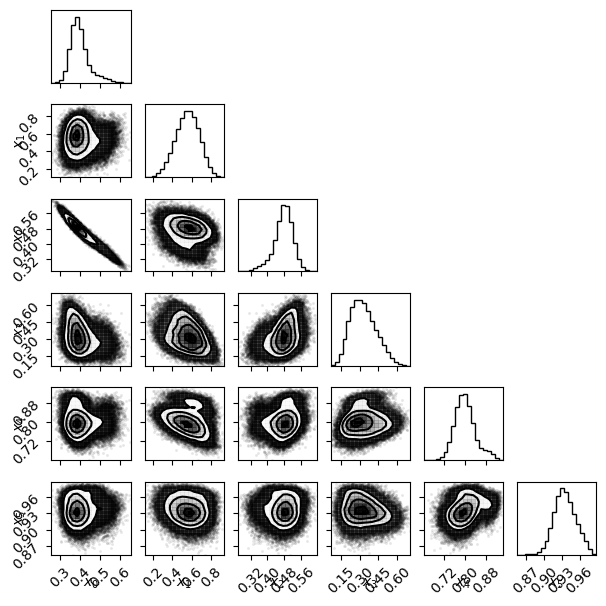

In [3]:
import dill
with open("/home/andrew/abm_violence/models/mixed_choice-v9/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp = vbmc_loaded.vp
vp.plot()
print("plotted")

plotted


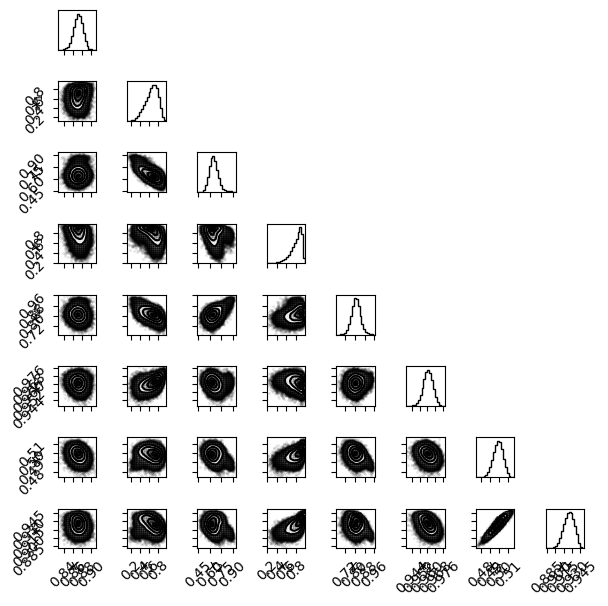

In [1]:
import dill
with open("/home/andrew/abm_violence/models/big_model-v6/vbmc.pkl", "rb") as f:
    vbmc_loaded = dill.load(f)
vp = vbmc_loaded.vp
vp.plot()
print("plotted")